In [1]:
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff

In [2]:
df = pd.read_csv("../data/small10/test1/checks.csv")

In [3]:
df

,check_id,similarity,answer,passage_id,question
0,0,0.484044,Редакции наперебой стараются обжулить Мартина.,361,Что происходит в карьере Мартина?
1,1,0.404895,Добыть деньги за публикации оказывается нелёгк...,361,Что происходит в карьере Мартина?
2,2,0.913715,У Морзов Мартин знакомится с Рэссом Бриссенден...,361,С кем знакомится Мартин у Морзов?
3,3,0.743306,"С Бриссенденом, а тот затем знакомит Мартина с...",361,С кем знакомится Мартин у Морзов?
4,4,0.802494,Спорит с выступающим и этим привлекает внимани...,361,"Что Мартин делает на митинге, который посетил ..."
...,...,...,...,...,...
113,113,0.752918,Автор говорит о запасе любви.,450,Про какой запас говорит автор?
114,114,0.821666,"Любовь красивая, любовь самоотверженная, любов...",450,Какие 3 рода любви упоминаются в тексте?
115,115,0.641773,"Красивая, самоотверженная, деятельная.",450,Какие 3 рода любви упоминаются в тексте?
116,116,0.480364,Для третьего рода любви - деятельной.,450,Для чего была рождена Софья Ивановна?


In [4]:
df_n = pd.read_csv("../data/b_samples_10/test1/checks.csv")

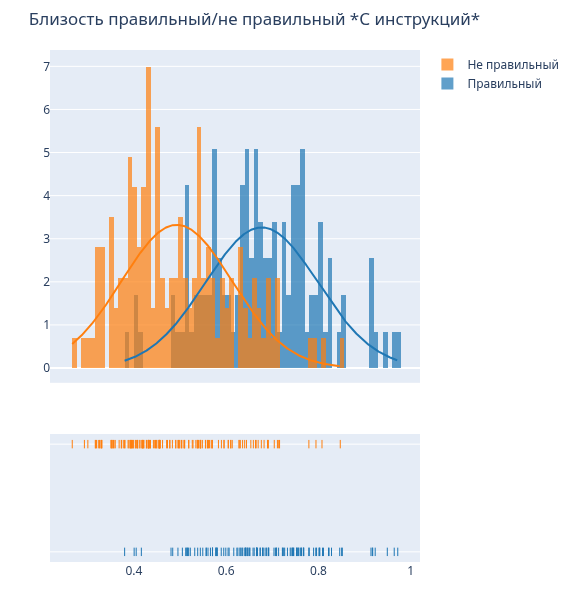

In [5]:
group_labels = ['Правильный', 'Не правильный']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot([df["similarity"], df_n["similarity"]], group_labels, bin_size=.01,
                         curve_type='normal', # override default 'kde'
                         rug_text=[df["check_id"],df_n["check_id"]]
                        )
# Add title
fig.update_layout(title_text='Близость правильный/не правильный *С инструкций*')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()

In [6]:
import plotly.express as px
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score


In [7]:
dfv = df[["check_id", "similarity"]]
dfv.insert(2, "verdict", 1)

dfv_n = df_n[["check_id", "similarity"]]
dfv_n.insert(2, "verdict", 0)

dfv_m = pd.concat([dfv, dfv_n],ignore_index=True)

In [8]:
y_test = dfv_m["verdict"].values 
y_scores = dfv_m["similarity"].values

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
ap_score = average_precision_score(y_test, y_scores)

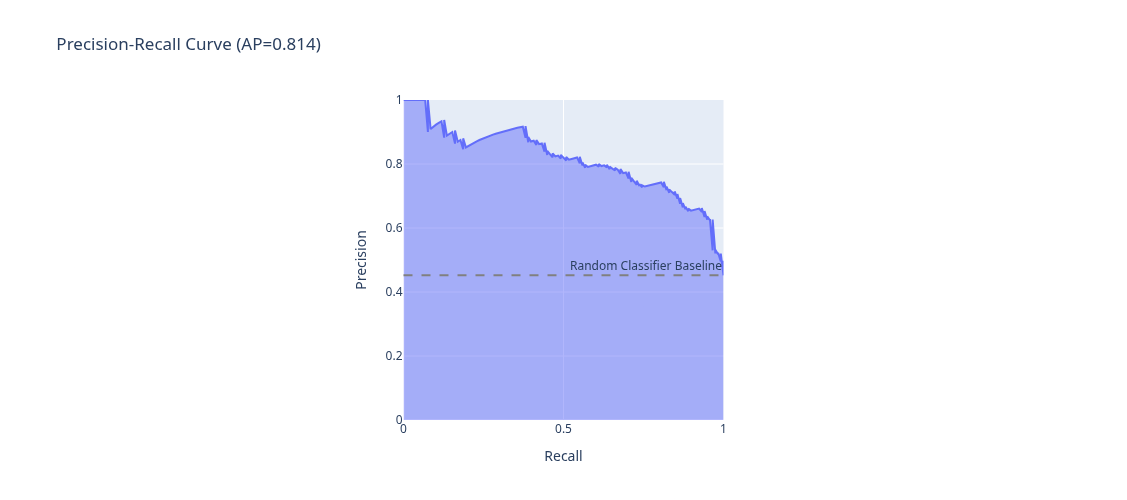

In [9]:
fig = px.area(
    x=recall, 
    y=precision,
    title=f'Precision-Recall Curve (AP={ap_score:.3f})',
    labels=dict(x='Recall', y='Precision'),
    width=700, 
    height=500
)

fig.update_layout(
    xaxis=dict(range=[0, 1], constrain='domain'),
    yaxis=dict(range=[0, 1], scaleanchor="x", scaleratio=1),
    hovermode='x unified'
)


baseline = sum(y_test) / len(y_test)
fig.add_hline(y=baseline, line_dash="dash", line_color="gray", 
              annotation_text="Random Classifier Baseline")

fig.show()